Import headers and definitions

## 1. Preprocesare și antrenare model MLP
Încărcare date, preprocesare, antrenare MLP Regressor pe setul complet de atribute și evaluarea performanței.


(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

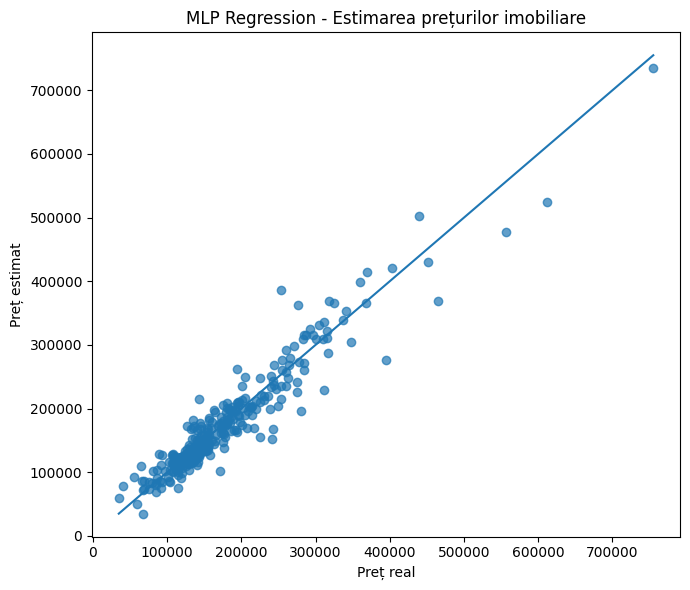

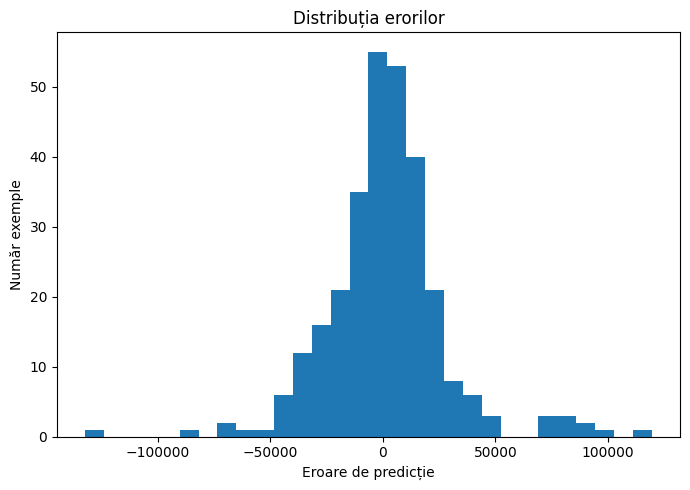

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Citire date
df = pd.read_csv("train.csv")

print(df.shape)
print(df.head())

# Separare intrări / ieșire
X = df.drop(columns=["SalePrice", "Id"])
y = df["SalePrice"]

# opțional: log-transform pentru preț, ajută mult la regresie
y_log = np.log1p(y)

# Coloane numerice și categorice
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocesare
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Împărțire train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Model MLP Regressor
mlp = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("mlp", mlp)
])

# Antrenare
model.fit(X_train, y_train)

# Predicție
y_pred_log = model.predict(X_test)

# revenim din log în preț real
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Evaluare
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("Rezultate MLP Regression:")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"R2   = {r2:.4f}")

# Grafic: preț real vs preț estimat
plt.figure(figsize=(7, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.7)
plt.xlabel("Preț real")
plt.ylabel("Preț estimat")
plt.title("MLP Regression - Estimarea prețurilor imobiliare")

min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()
plt.show()

# Grafic eroare
errors = y_test_real - y_pred_real

plt.figure(figsize=(7, 5))
plt.hist(errors, bins=30)
plt.xlabel("Eroare de predicție")
plt.ylabel("Număr exemple")
plt.title("Distribuția erorilor")
plt.tight_layout()
plt.show()

df["SalePrice"].describe()

## 2. Compararea arhitecturilor neuronale
Benchmarking pe 6 configurații MLP pentru identificarea arhitecturii optime.

In [ ]:
hidden_list = [
    (16,),
    (32,),
    (64,),
    (64, 32),
    (128, 64),
    (128, 64, 32)
]

results = []

for hidden in hidden_list:
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("mlp", mlp)
    ])

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    results.append((hidden, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=["Hidden layers", "RMSE", "MAE", "R2"])
print(results_df)

   Hidden layers          RMSE           MAE        R2
0          (16,)  30790.152328  20149.928523  0.876402
1          (32,)  28659.837117  19488.545036  0.892914
2          (64,)  27036.014341  18576.444278  0.904705
3       (64, 32)  29926.314548  20449.326774  0.883240
4      (128, 64)  38134.358628  24421.172810  0.810408
5  (128, 64, 32)  31417.756024  21193.807237  0.871312


## 3. Model simplificat prin selecția atributelor
Filtrare atribute numerice cu |corr| > 0.3, păstrarea variabilelor categorice și reantrenare pe setul redus.

Atribute numerice relevante:
['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']

Numar total atribute:
61

Rezultate model optimizat:
   Hidden layers          RMSE           MAE        R2
0          (16,)  34819.271291  23403.419635  0.841939
1          (32,)  31804.040706  21440.075264  0.868129
2          (64,)  36174.742788  21689.786562  0.829393
3       (64, 32)  37671.745520  22765.774584  0.814980
4      (128, 64)  38649.534643  23357.222684  0.805251
5  (128, 64, 32)  38300.291288  23987.570794  0.808755

Cea mai buna arhitectura:
(32,)


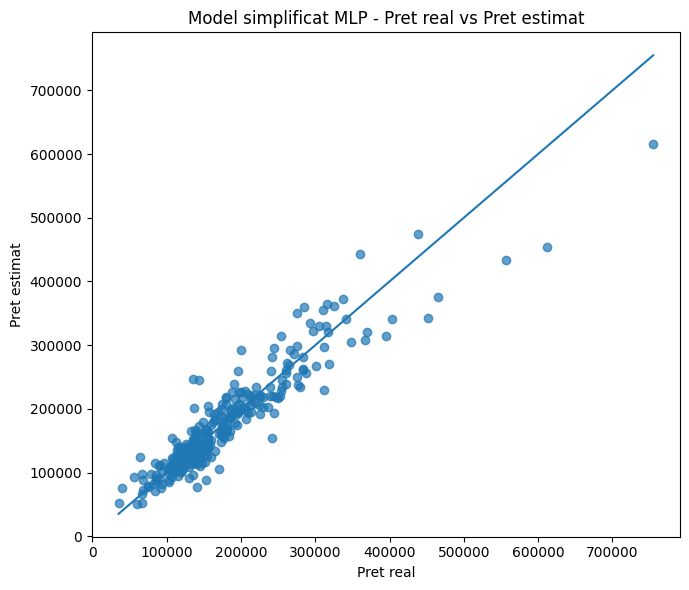

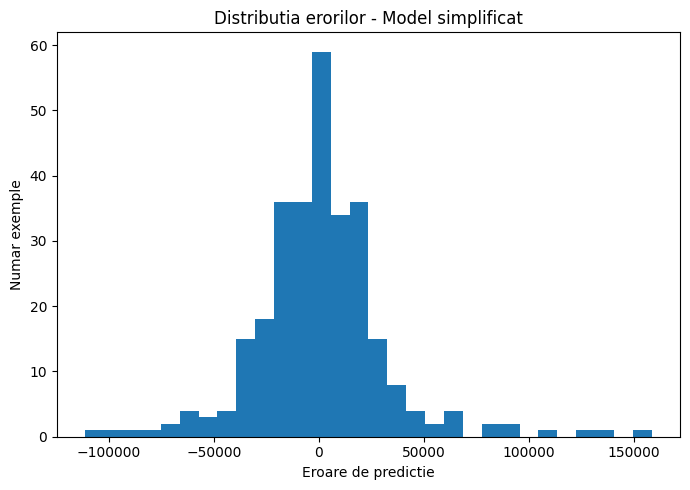

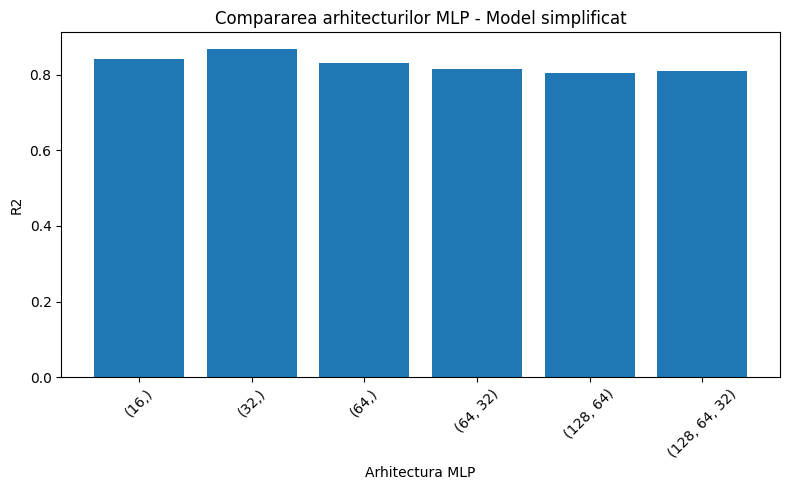

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


#  Citire date
df = pd.read_csv("train.csv")

#  Separare target
y = df["SalePrice"]

# transformare log
y_log = np.log1p(y)

# Corelatii numerice

corr_matrix = df.corr(numeric_only=True)

saleprice_corr = corr_matrix["SalePrice"].abs()


# Selectam doar atributele numerice relevante

selected_numeric = saleprice_corr[saleprice_corr > 0.3].index.tolist()

# eliminam target
selected_numeric.remove("SalePrice")

print("Atribute numerice relevante:")
print(selected_numeric)

# Construim dataset final

selected_features = (
    selected_numeric +
    categorical_features
)

X = df[selected_features]

print("\nNumar total atribute:")
print(len(selected_features))


# Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)


# Separare numerice/categorice

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


# Preprocesare

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer,
         categorical_features)
    ]
)

# Comparare arhitecturi

hidden_list = [
    (16,),
    (32,),
    (64,),
    (64, 32),
    (128, 64),
    (128, 64, 32)
]

results = []

for hidden in hidden_list:

    mlp = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("mlp", mlp)
    ])

    # antrenare
    model.fit(X_train, y_train)

    # predictie
    y_pred_log = model.predict(X_test)

    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # metrici
    rmse = np.sqrt(
        mean_squared_error(
            y_test_real,
            y_pred_real
        )
    )

    mae = mean_absolute_error(
        y_test_real,
        y_pred_real
    )

    r2 = r2_score(
        y_test_real,
        y_pred_real
    )

    results.append((
        hidden,
        rmse,
        mae,
        r2
    ))


# Tabel rezultate

results_df = pd.DataFrame(
    results,
    columns=["Hidden layers", "RMSE", "MAE", "R2"]
)

print("\nRezultate model optimizat:")
print(results_df)


# Alegem cel mai bun model dupa R2

best_index = results_df["R2"].idxmax()
best_hidden = results_df.loc[best_index, "Hidden layers"]

print("\nCea mai buna arhitectura:")
print(best_hidden)


# Reantrenam cel mai bun model pentru grafice

best_mlp = MLPRegressor(
    hidden_layer_sizes=best_hidden,
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42
)

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("mlp", best_mlp)
])

best_model.fit(X_train, y_train)

y_pred_log = best_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)


# Grafic: Pret real vs Pret estimat

plt.figure(figsize=(7, 6))

plt.scatter(y_test_real, y_pred_real, alpha=0.7)

plt.xlabel("Pret real")
plt.ylabel("Pret estimat")
plt.title("Model simplificat MLP - Pret real vs Pret estimat")

min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()
plt.show()


# Grafic: Distributia erorilor

errors = y_test_real - y_pred_real

plt.figure(figsize=(7, 5))

plt.hist(errors, bins=30)

plt.xlabel("Eroare de predictie")
plt.ylabel("Numar exemple")
plt.title("Distributia erorilor - Model simplificat")

plt.tight_layout()
plt.show()


# Grafic: Compararea arhitecturilor dupa R2


plt.figure(figsize=(8, 5))

plt.bar(results_df["Hidden layers"].astype(str), results_df["R2"])

plt.xlabel("Arhitectura MLP")
plt.ylabel("R2")
plt.title("Compararea arhitecturilor MLP - Model simplificat")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()